## Galaxy Zoo

Toy galaxies as SPH, FIX (uniform fixed grid) and AMR (pseudo-AMR) yt datasets.

### Setup

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import SVG, Image, display

import zoo as g

OUTDIR = Path("out")
OUTDIR.mkdir(exist_ok=True)

PARTICLE_CACHE = OUTDIR / "zoo_cache.pkl"
FRAME_CACHE = OUTDIR / "zoo_frames.pkl"

plt.rcParams["figure.dpi"] = 80

### Particles

Simulated once and cached; stale caches regenerate.

In [2]:
results = g.load_or_generate(PARTICLE_CACHE)

#### Mass Budget

Masses follow from each galaxy's potential; $f_b = M_b / M_\mathrm{dyn}$.

In [3]:
g.print_mass_budget(g.mass_budget(results))

Galaxy                Box / kpc  V / km/s  M_b / Msun  M_dyn / Msun   f_b
01_grand_design              20       220    5.91e+10      1.12e+11  0.53
02_tightly_wound             20       250    7.56e+10      1.44e+11  0.52
03_flocculent                16       170    2.07e+10      5.34e+10  0.39
04_barred_spiral             20       220    6.54e+10      1.12e+11  0.58
05_lenticular                16       230    5.80e+10      9.78e+10  0.59
06_elliptical_e0             20       254    1.40e+11      1.50e+11  0.94
07_elliptical_e5             20       185    7.72e+10      8.00e+10  0.97
08_interacting_pair          60       220    8.64e+10      5.06e+11  0.17
09_merger_remnant           100       220    7.74e+10      4.50e+11  0.17
10_dwarf_irregular           10       120    4.28e+08      4.16e+09  0.10


### Montages

Density of every galaxy, one colour scale per galaxy and view.

In [4]:
try:
    with open(FRAME_CACHE, "rb") as f:
        frames = pickle.load(f)
except (FileNotFoundError, EOFError):
    frames = {}

for name in g.ORDER:
    if frames.get(name, {}).get("version") != g.CACHE_VERSION:
        frames[name] = g.render_galaxy(name, results[name], outdir=str(OUTDIR))
        with open(FRAME_CACHE, "wb") as f:
            pickle.dump(frames, f)
frames = {k: v for k, v in frames.items() if k in g.ORDER}

#### Projections

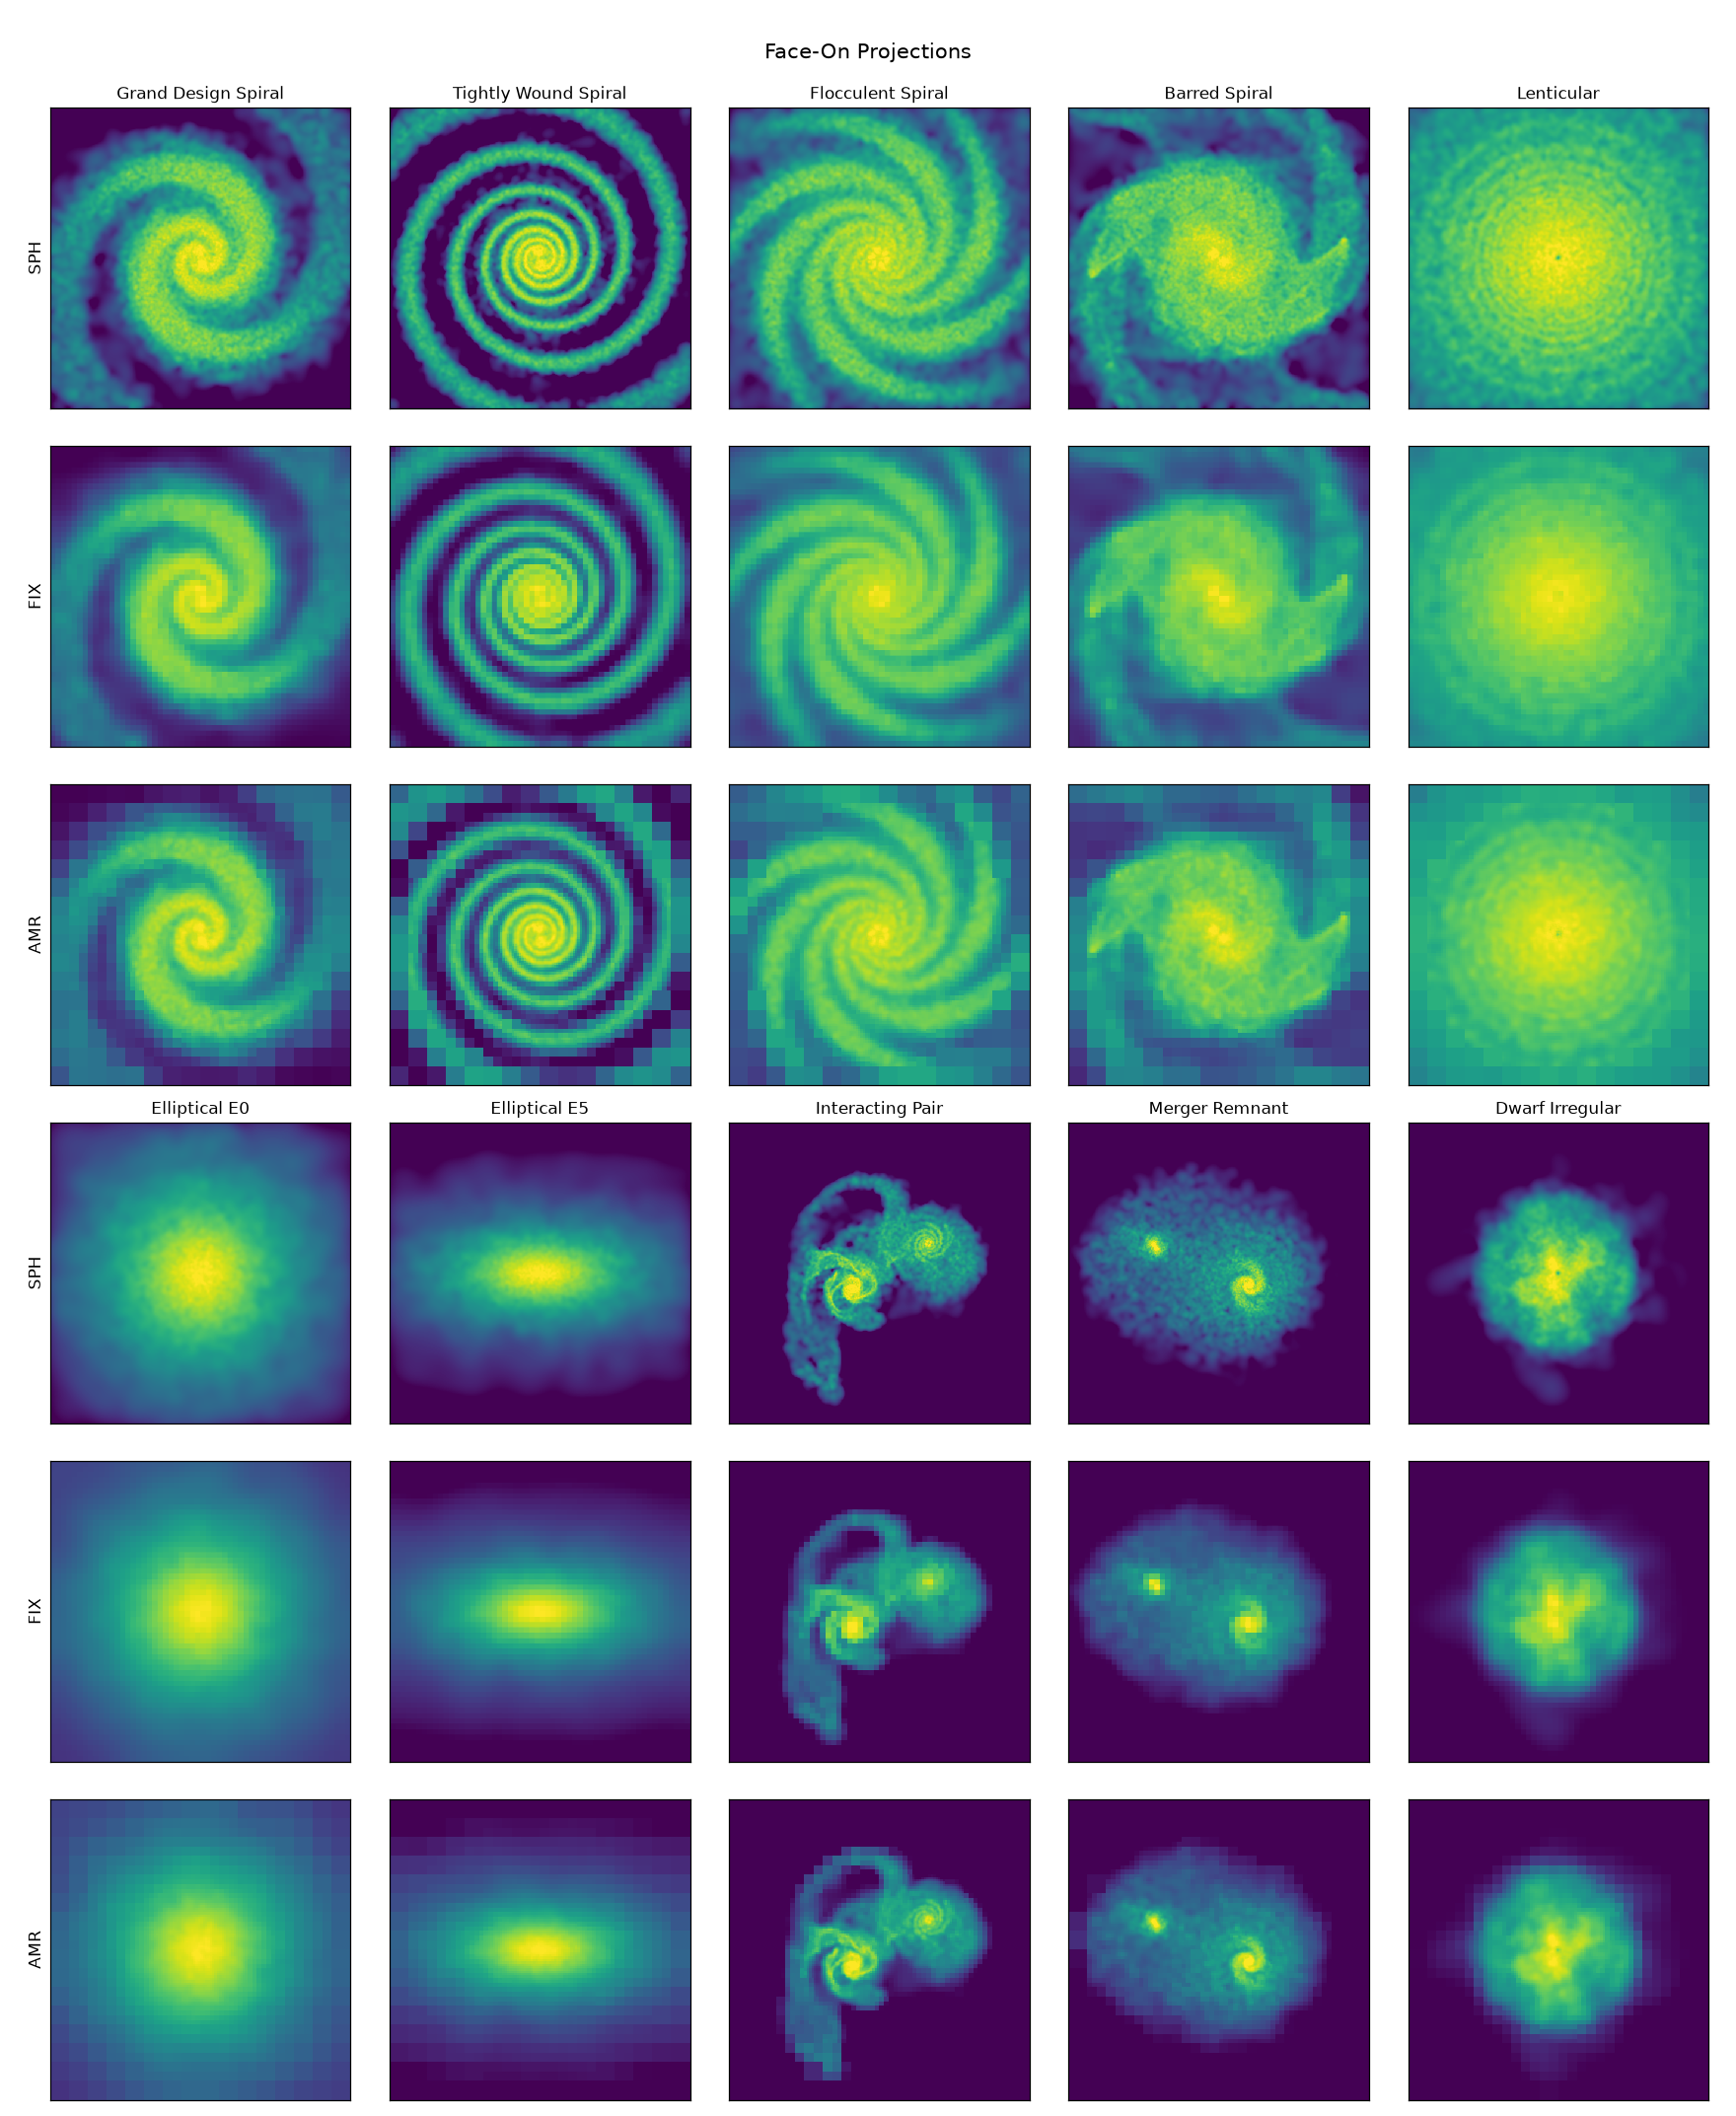

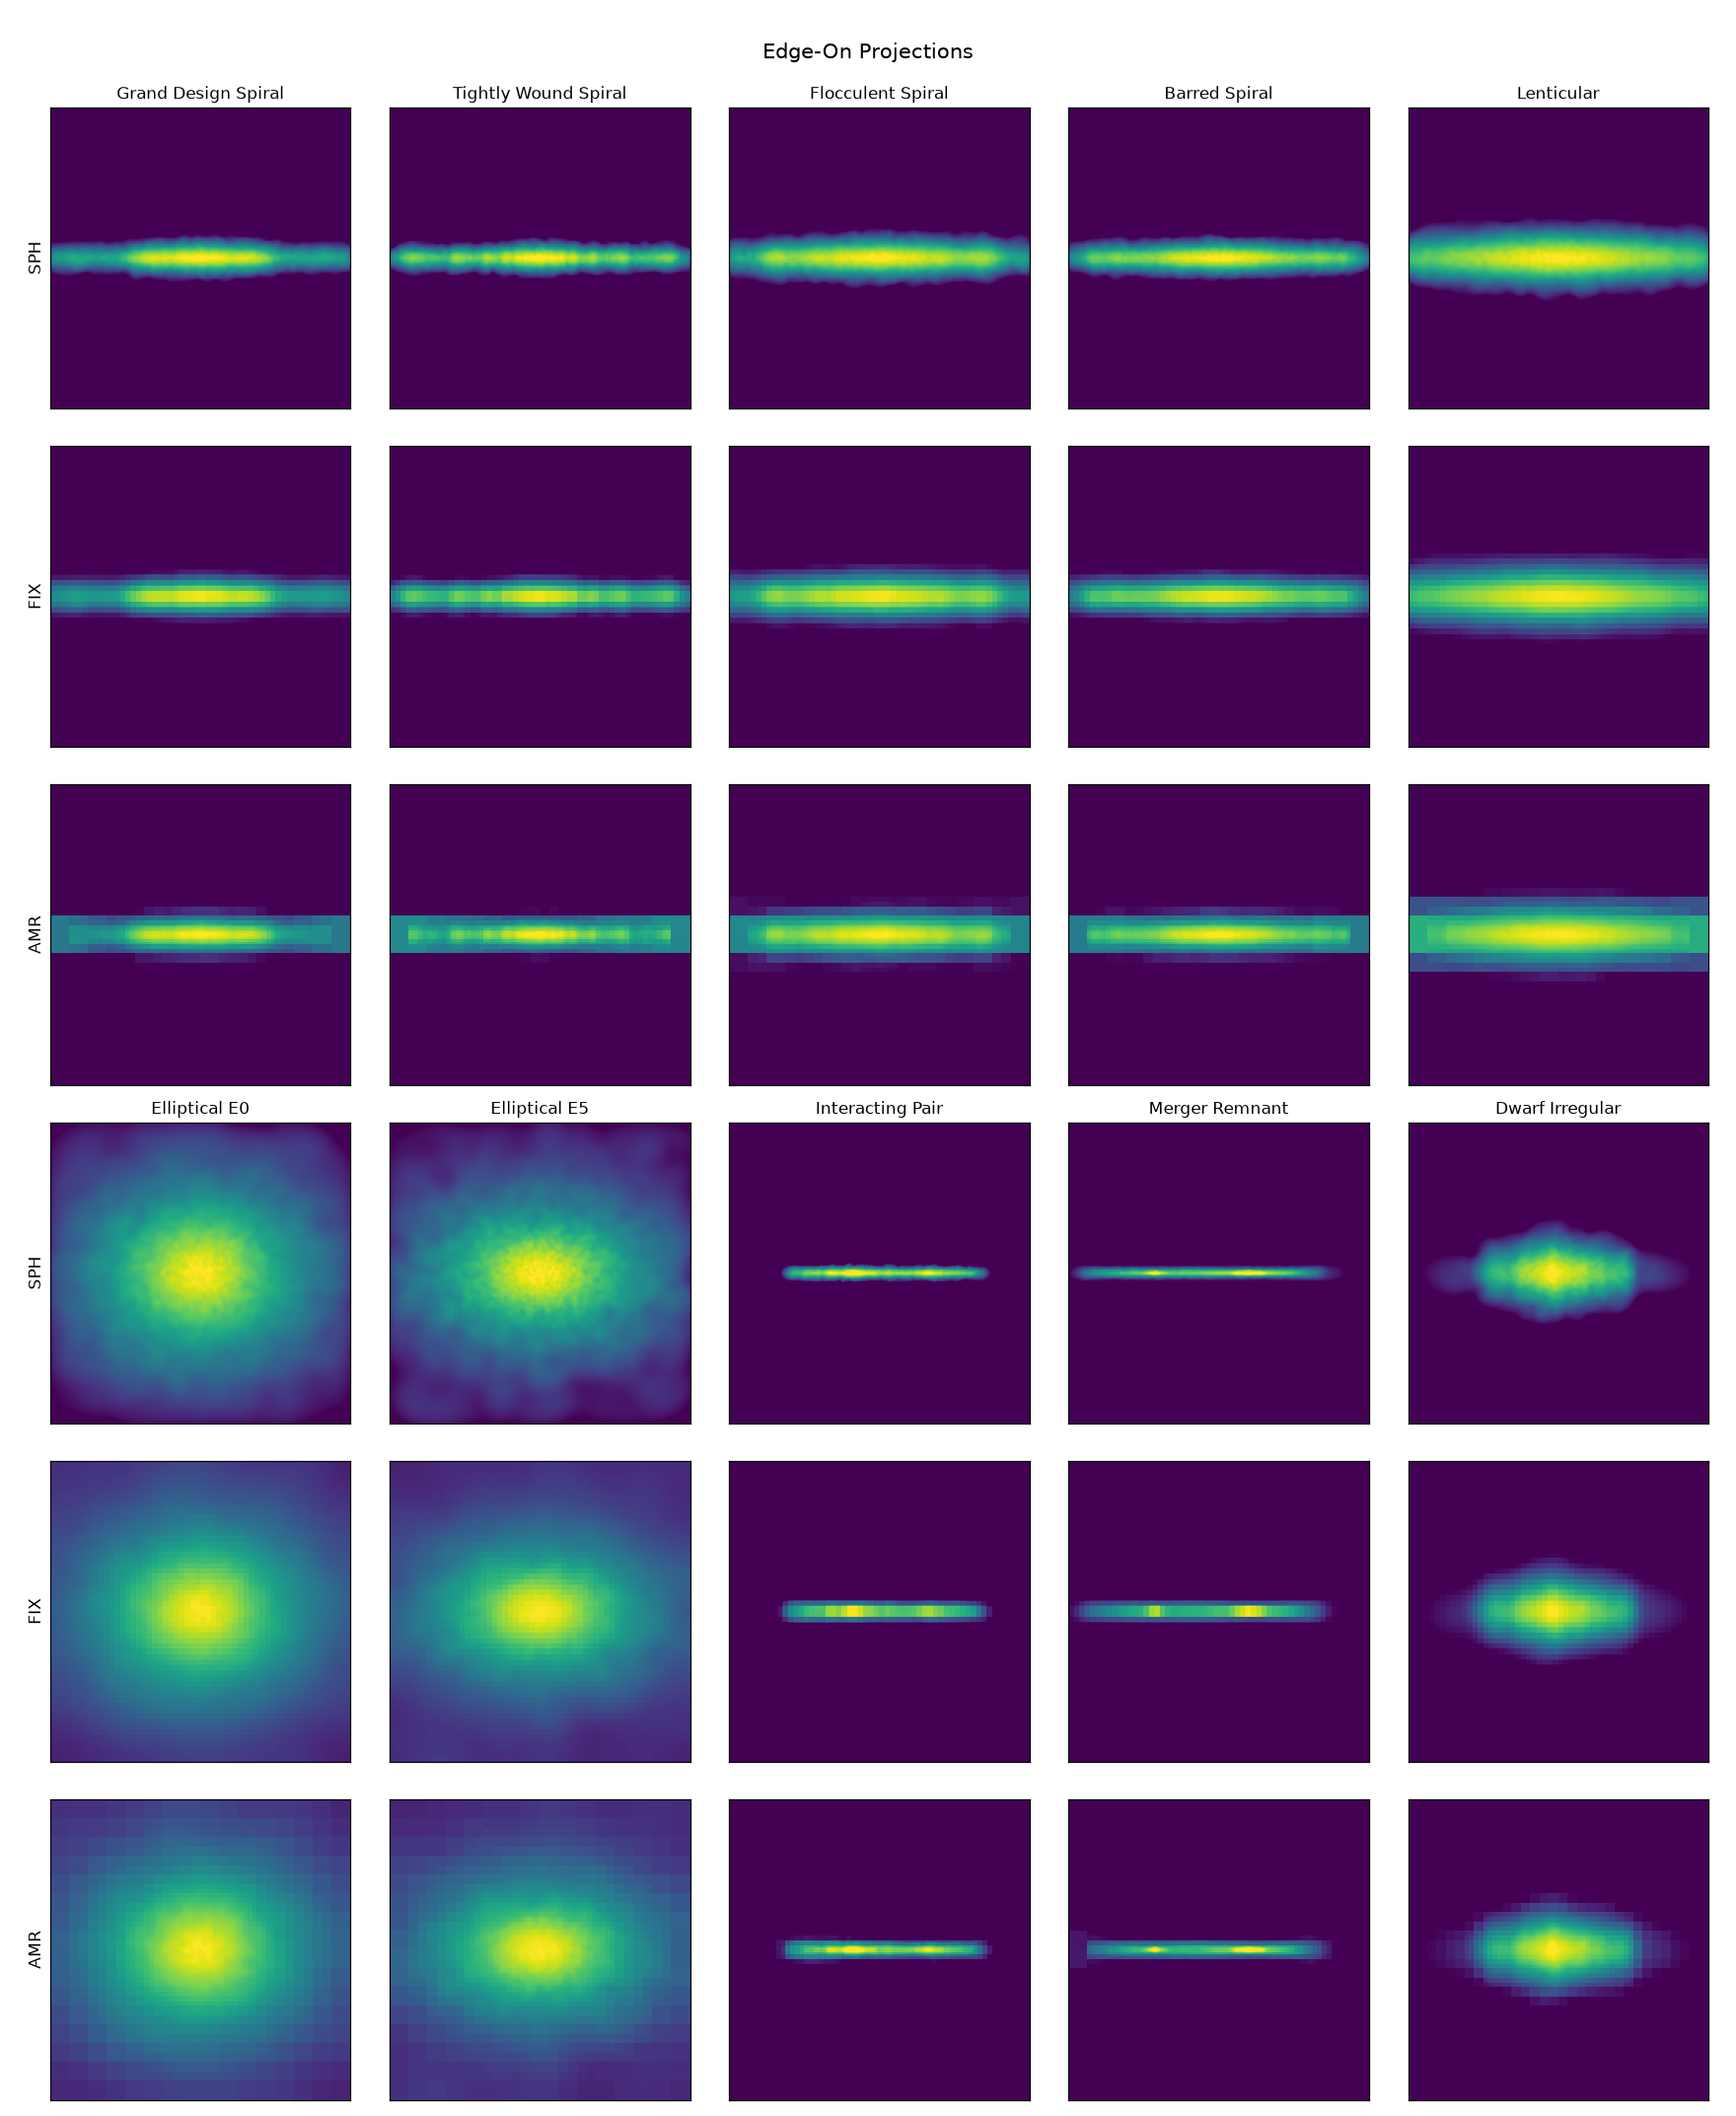

In [5]:
g.make_montages(frames, kind="proj", outdir=str(OUTDIR))
for view in ("face", "edge"):
    display(Image(filename=str(OUTDIR / f"montage_{view}_proj.png")))

#### Slices

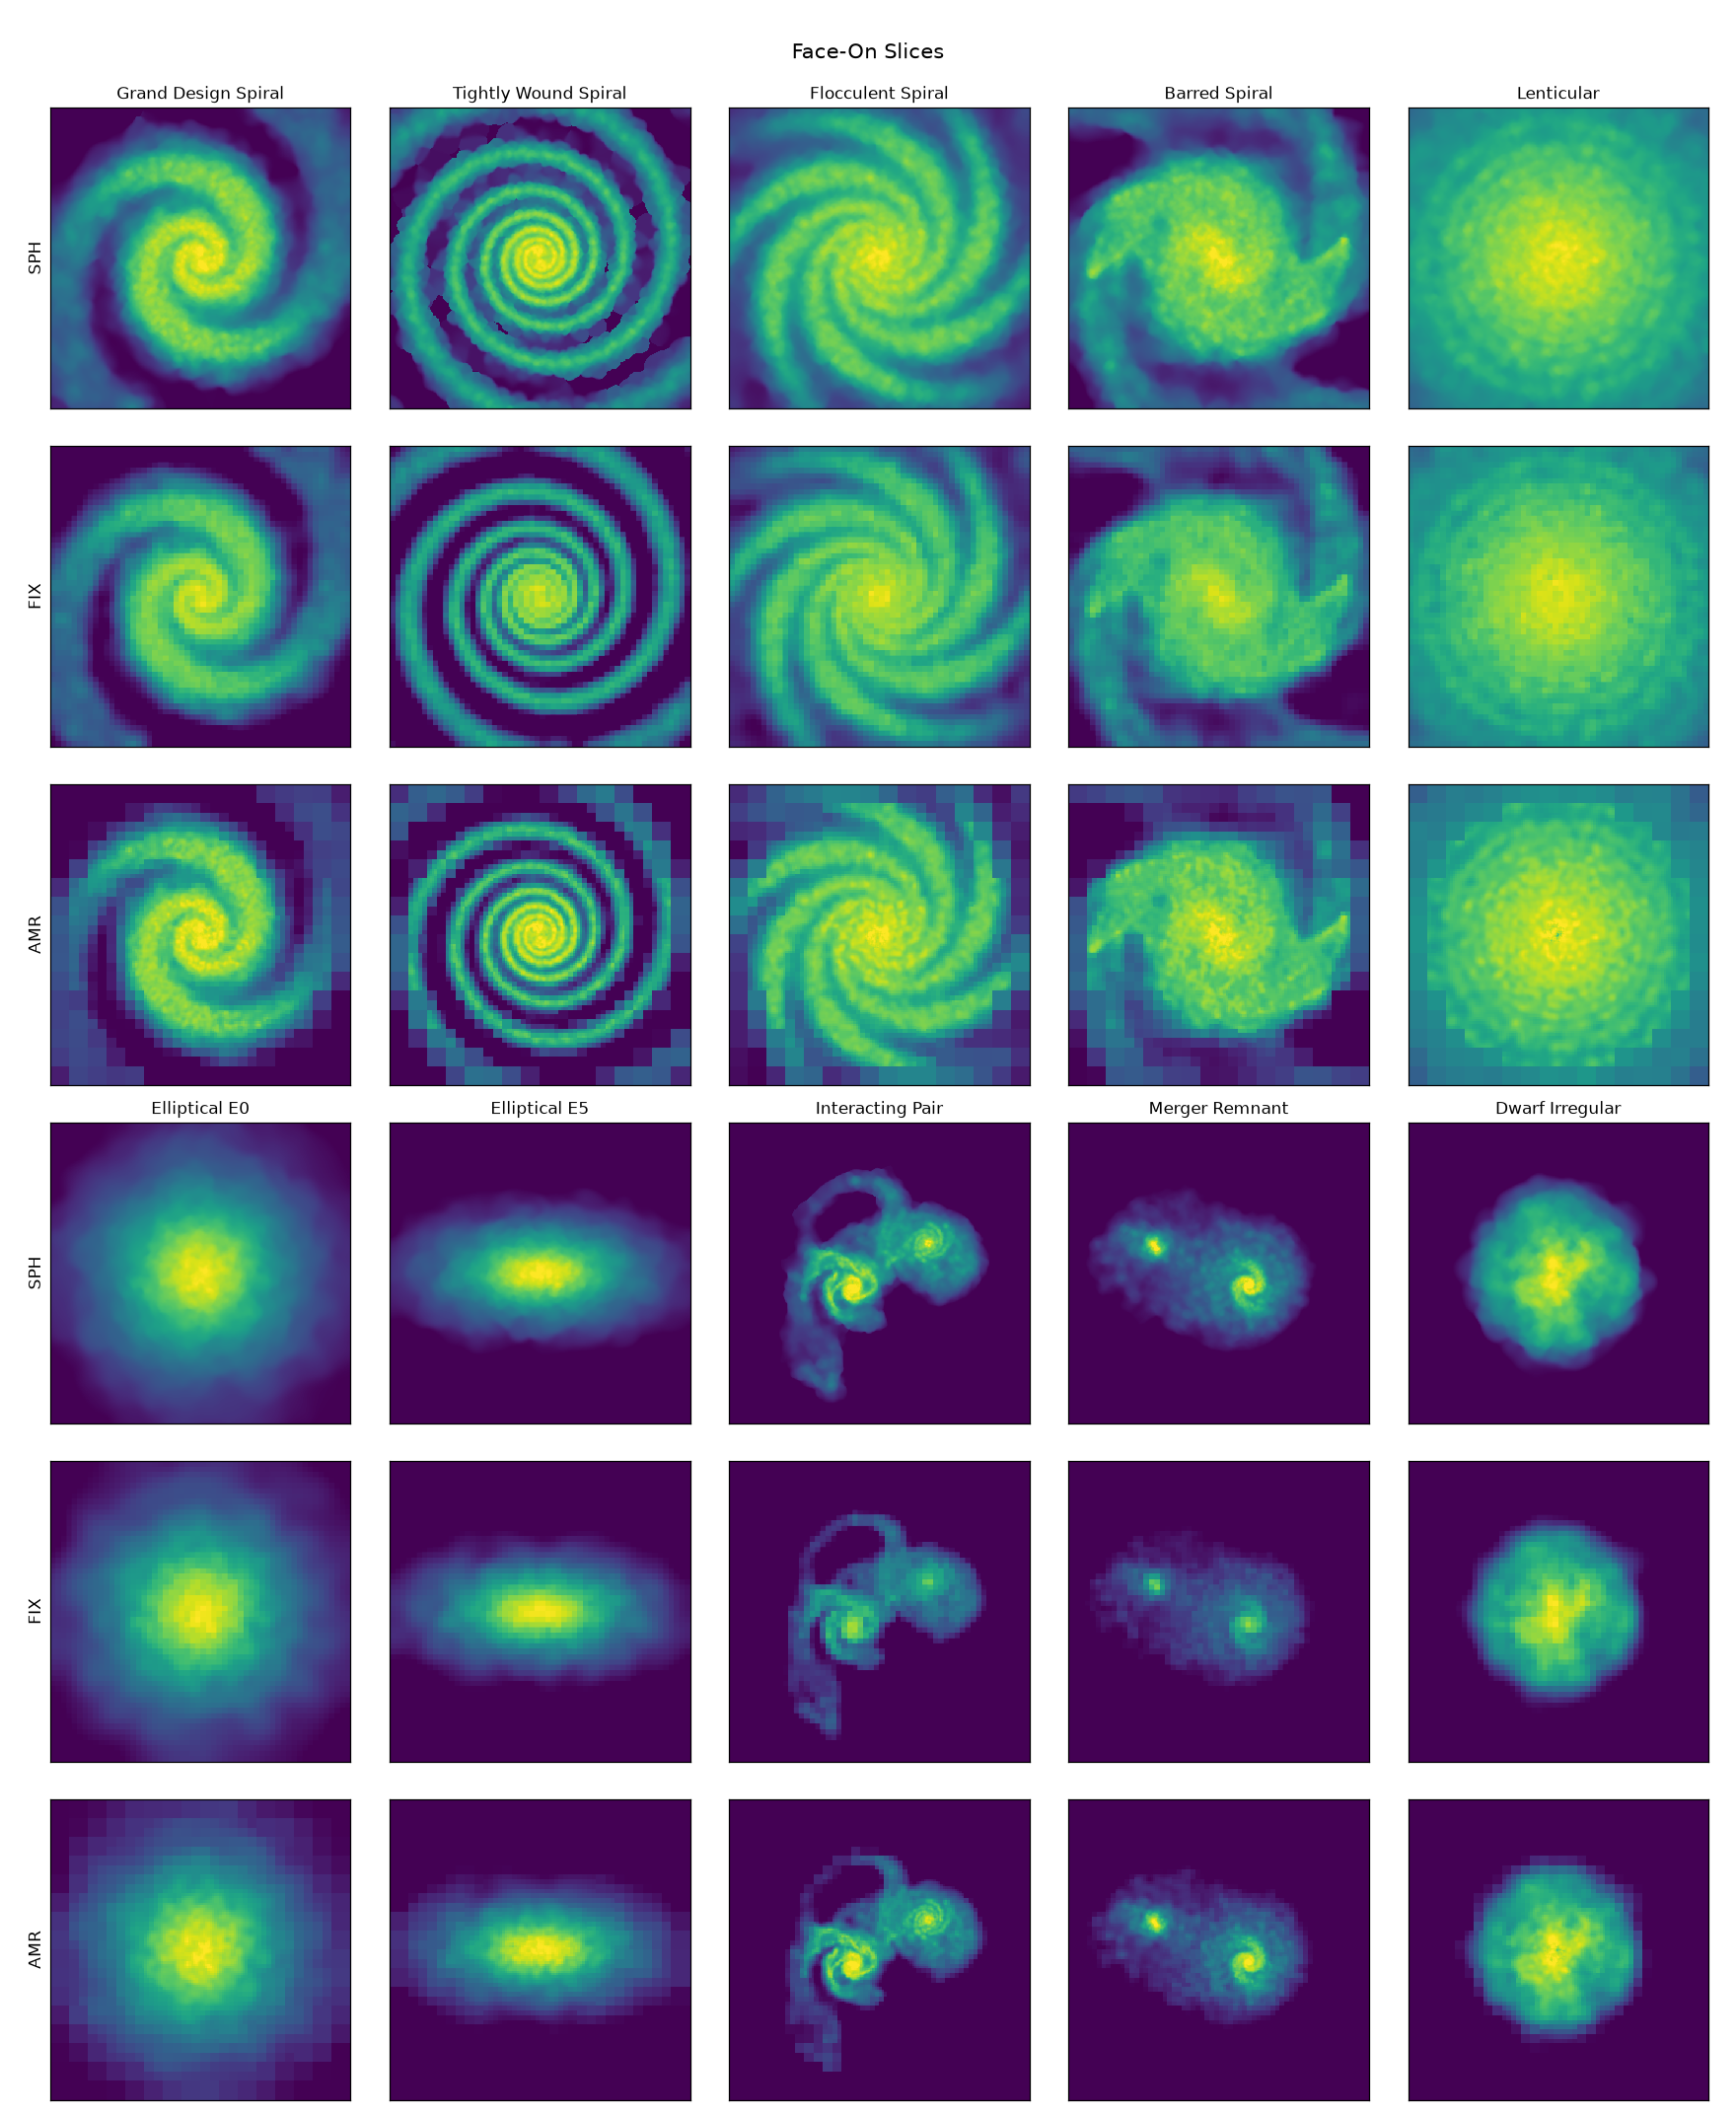

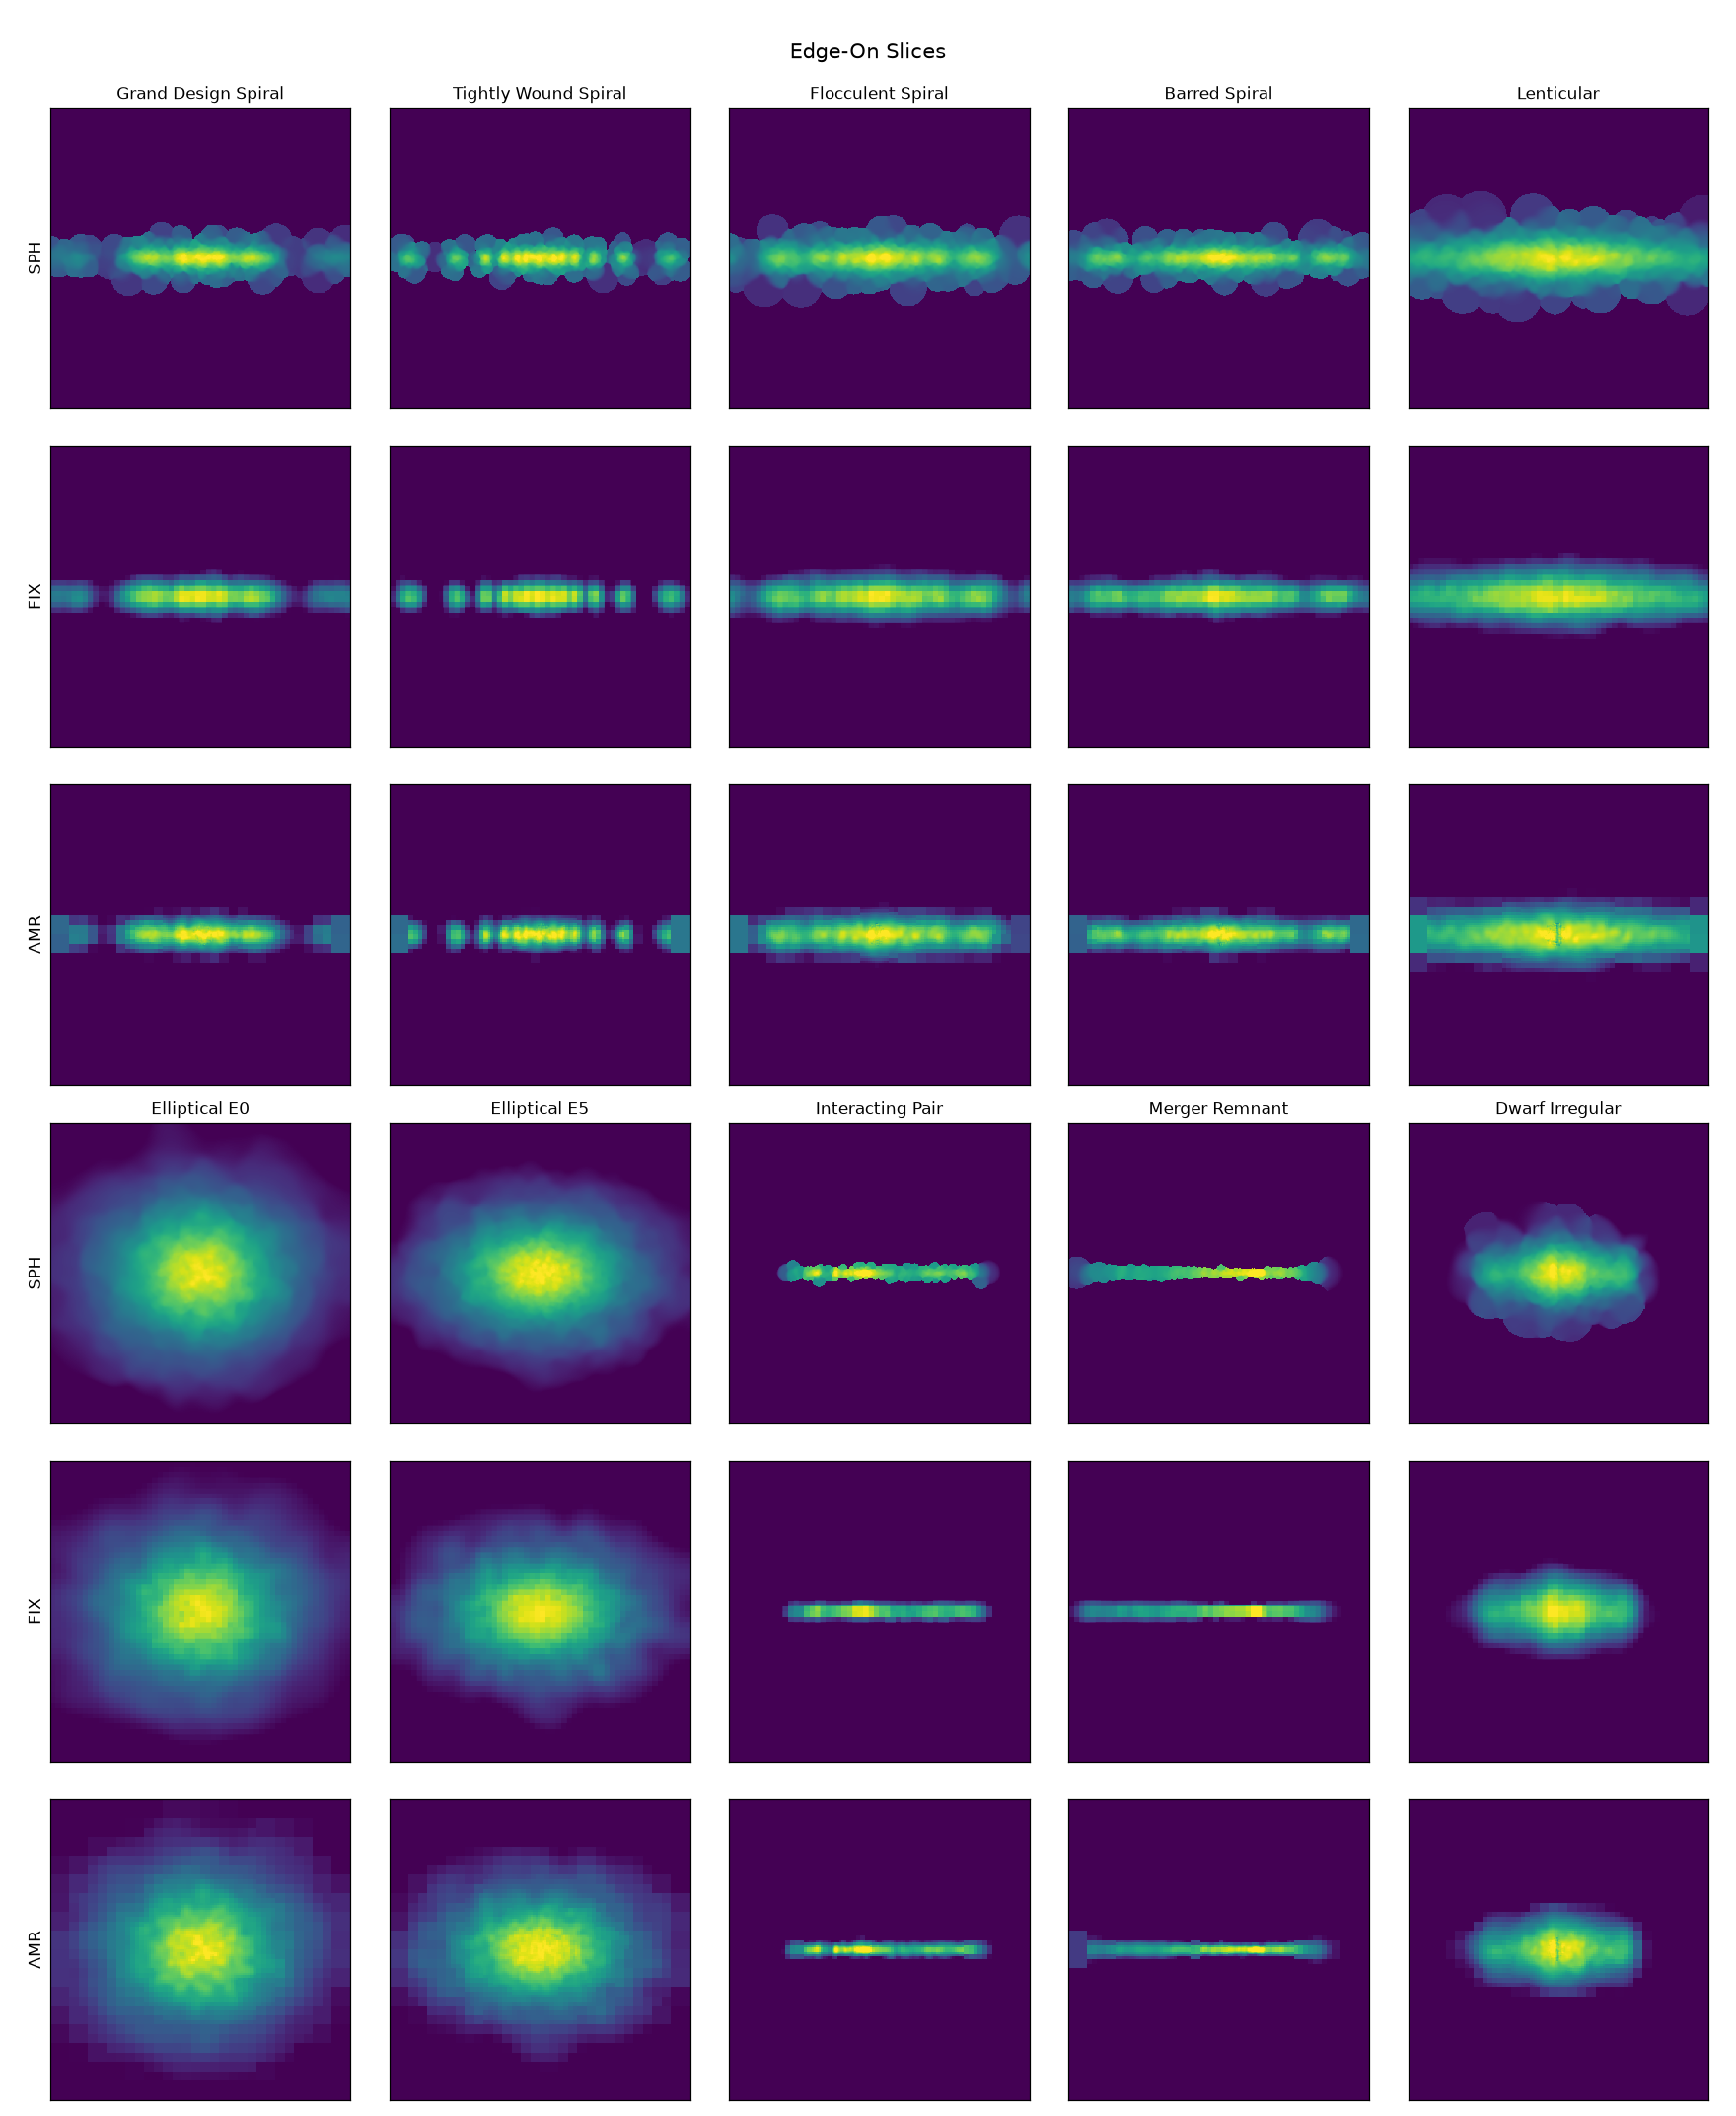

In [6]:
g.make_montages(frames, kind="slic", outdir=str(OUTDIR))
for view in ("face", "edge"):
    display(Image(filename=str(OUTDIR / f"montage_{view}_slic.png")))

### Fields and Profiles

Temperature and pressure are kinetic, from the local velocity dispersion: $T = \mu m_p \sigma^2 / k_B$, $P = \rho \sigma^2$.
Disk velocities combine circular speed, arm streaming and the isothermal-sheet dispersion.

In [7]:
def field_maps(name, gal, dsets):
    imgs = {m: {k: g.field_images(dsets[m], gal, k) for k in g.KINDS} for m in g.METHODS}
    for kind in g.KINDS:
        for view in ("face", "edge"):
            fig = g.plot_field_grid({m: imgs[m][kind] for m in g.METHODS}, gal, view, kind)
            fig.savefig(OUTDIR / f"{name}_{view}_{kind}.png", dpi=110)
            plt.show()


def profiles(name, gal, dsets):
    targets = g.profile_targets(gal)
    for i, (c, rs, label) in enumerate(targets):
        prof = {m: g.radial_profiles(dsets[m], gal, center=c, r_scale_kpc=rs) for m in g.METHODS}
        fig = g.plot_profiles(prof, gal, label)
        path = OUTDIR / f"{name}_profile{f'_{i + 1}' if len(targets) > 1 else ''}.svg"
        fig.savefig(path)
        plt.close(fig)
        display(SVG(filename=str(path)))

#### Grand Design Spiral

Arms are density and pressure ridges; temperature falls outward with the surface density.

##### Maps

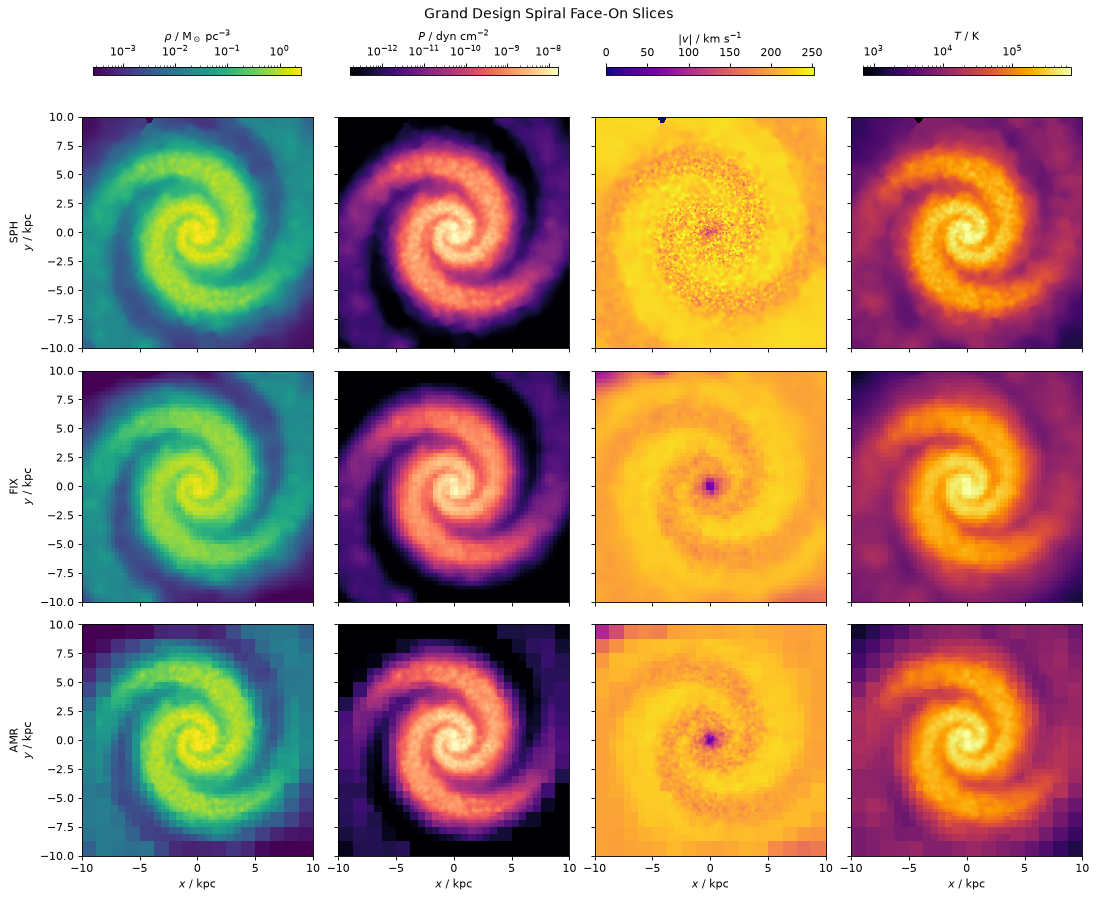

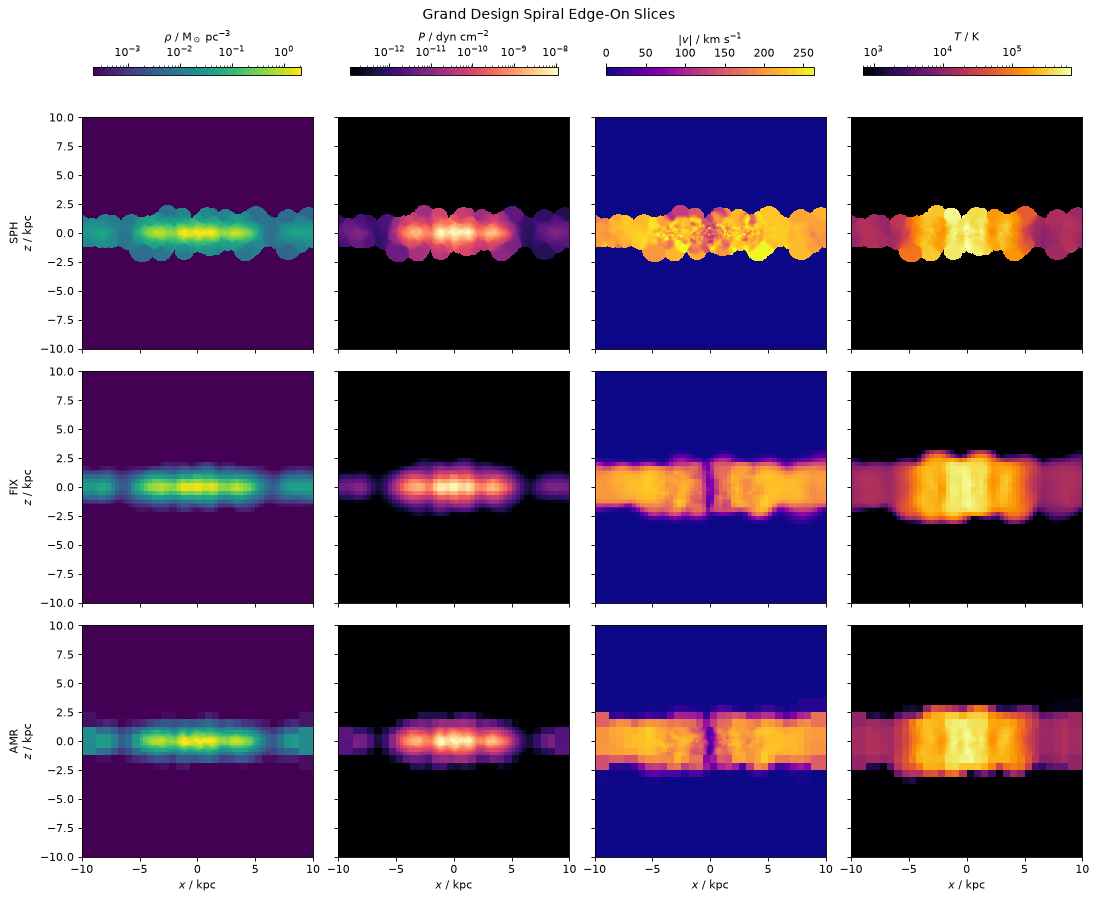

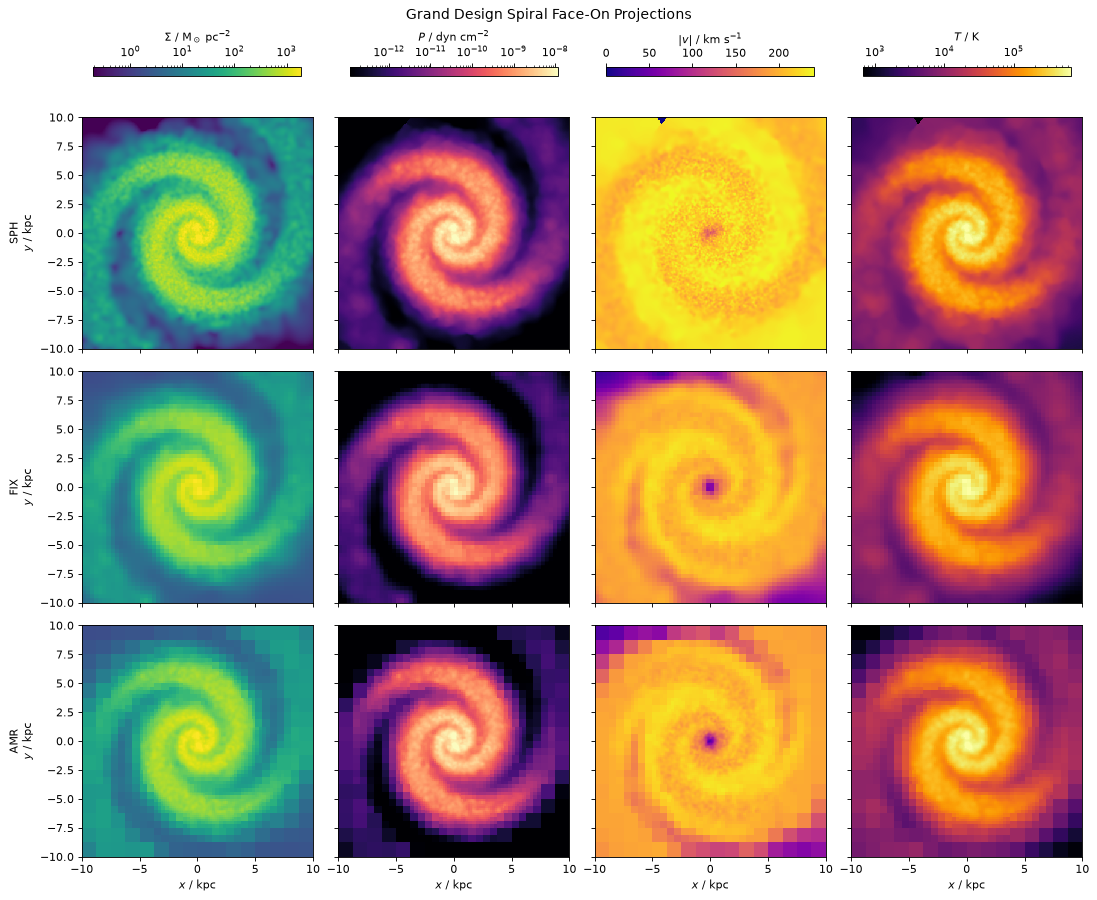

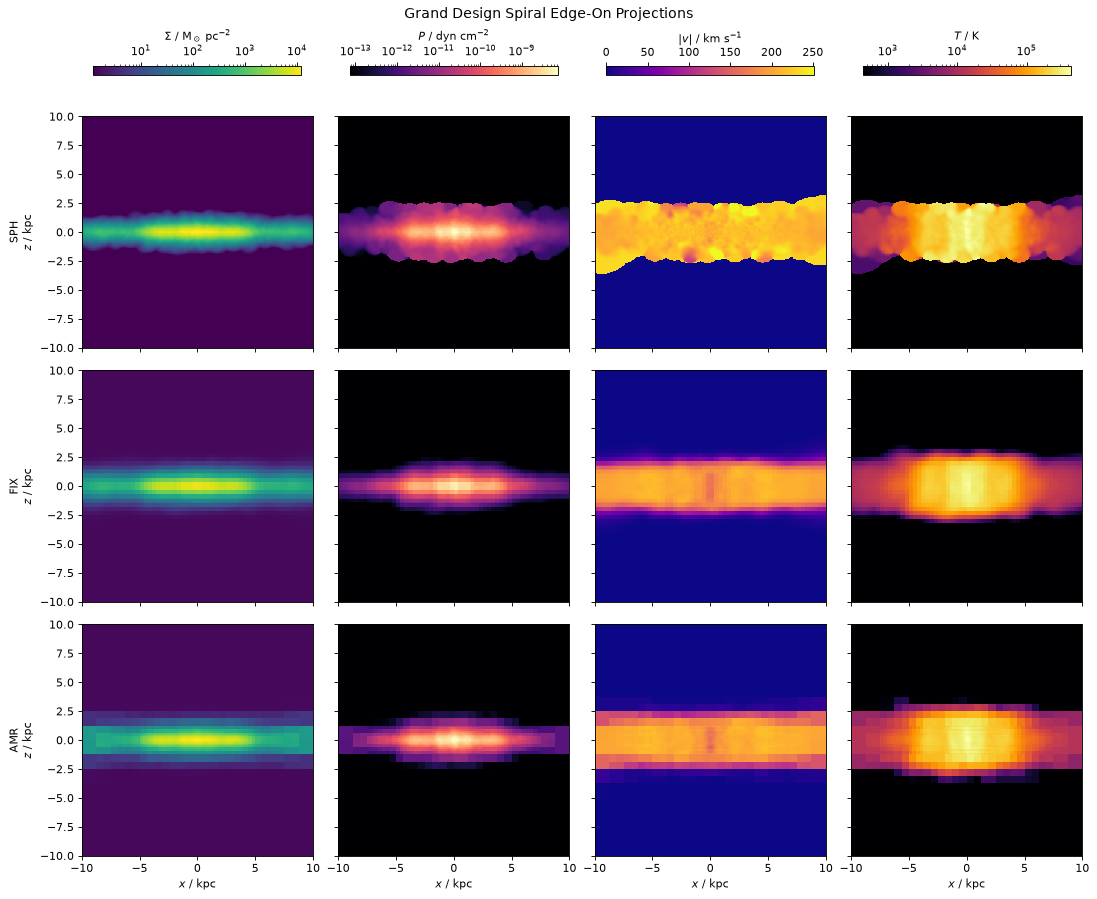

In [8]:
name = "01_grand_design"
gal = g.prepare_galaxy(name, results[name])
dsets = {m: g.build_ds(gal, m)[0] for m in g.METHODS}
field_maps(name, gal, dsets)

##### Native yt


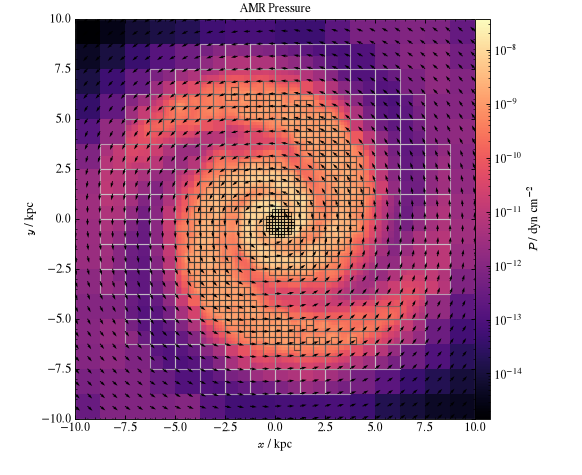

In [9]:
g.yt_plot(dsets["amr"], "z", "slic", field="pressure", grids=True, velocity=True,
          title="AMR Pressure")

##### Profiles

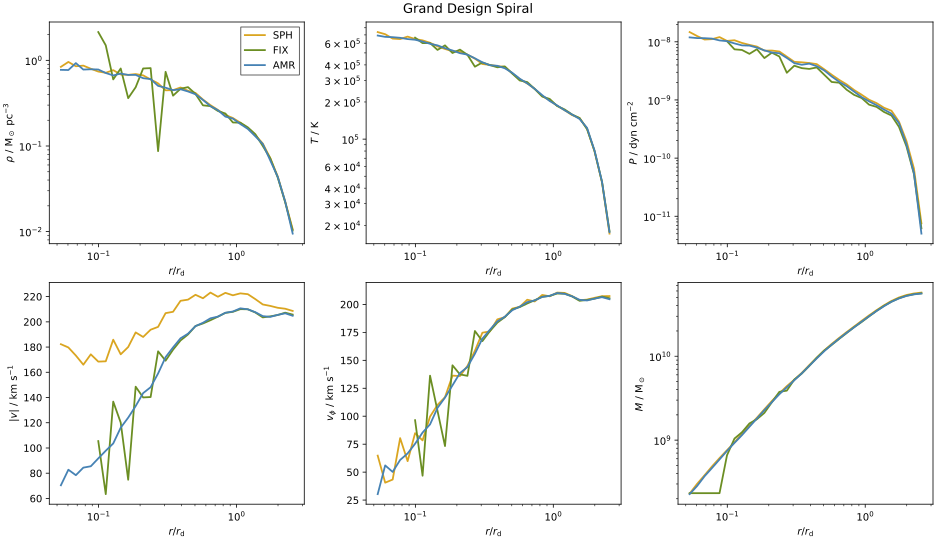

In [10]:
profiles(name, gal, dsets)
del dsets

#### Merger Remnant

Two nuclei in a common envelope of tidal debris; profiles around each nucleus.

##### Maps

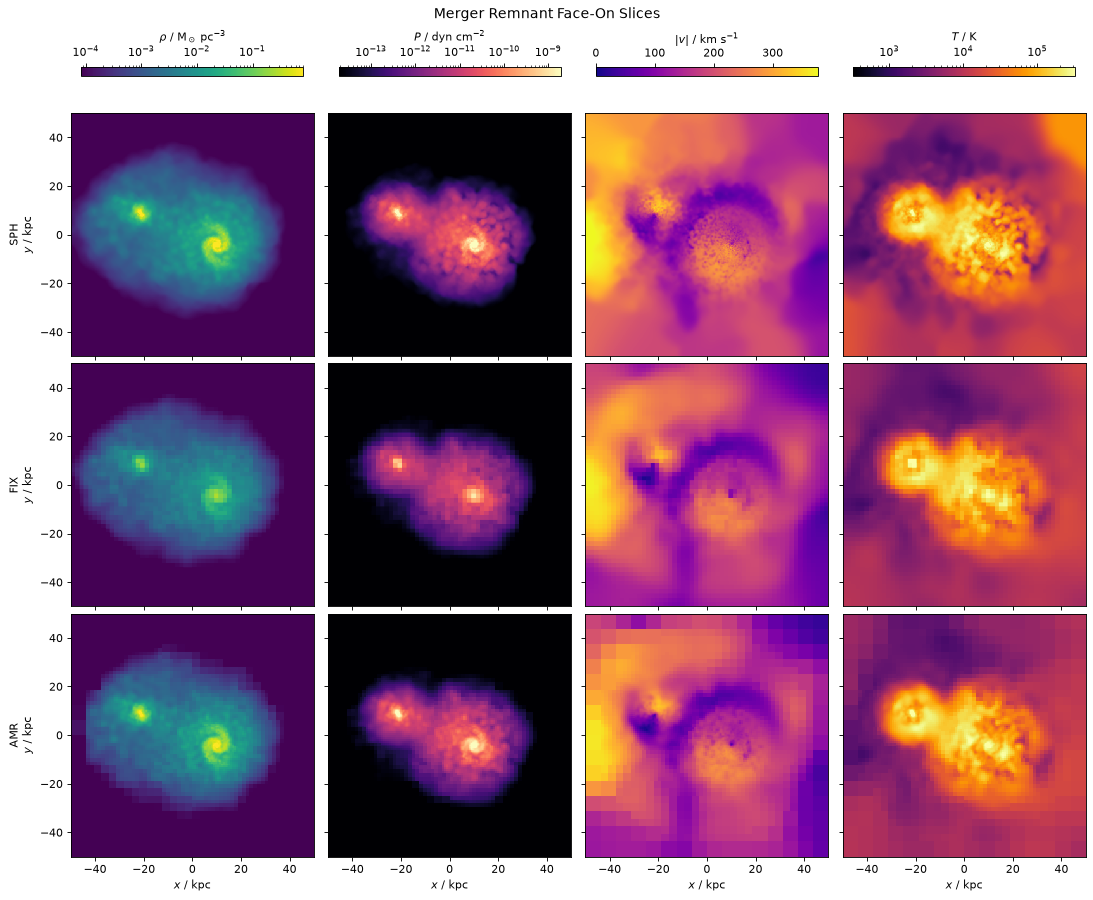

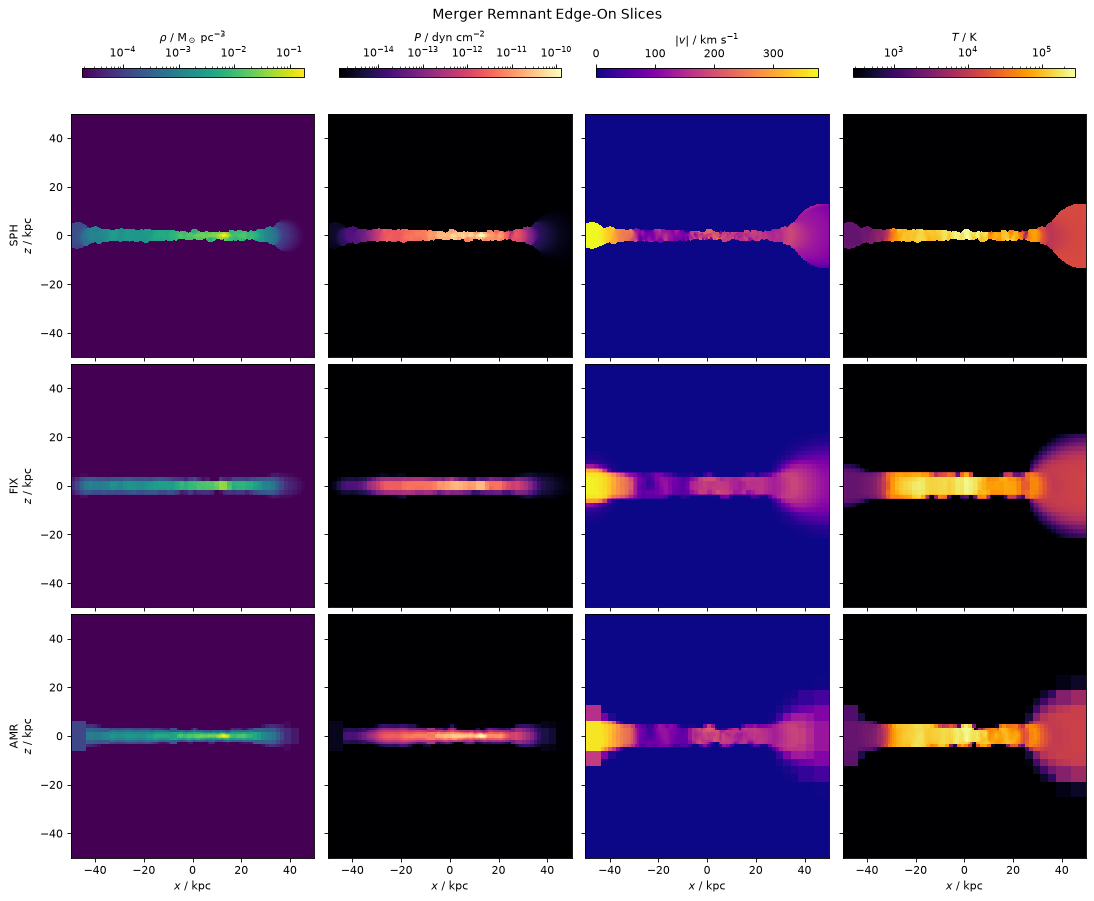

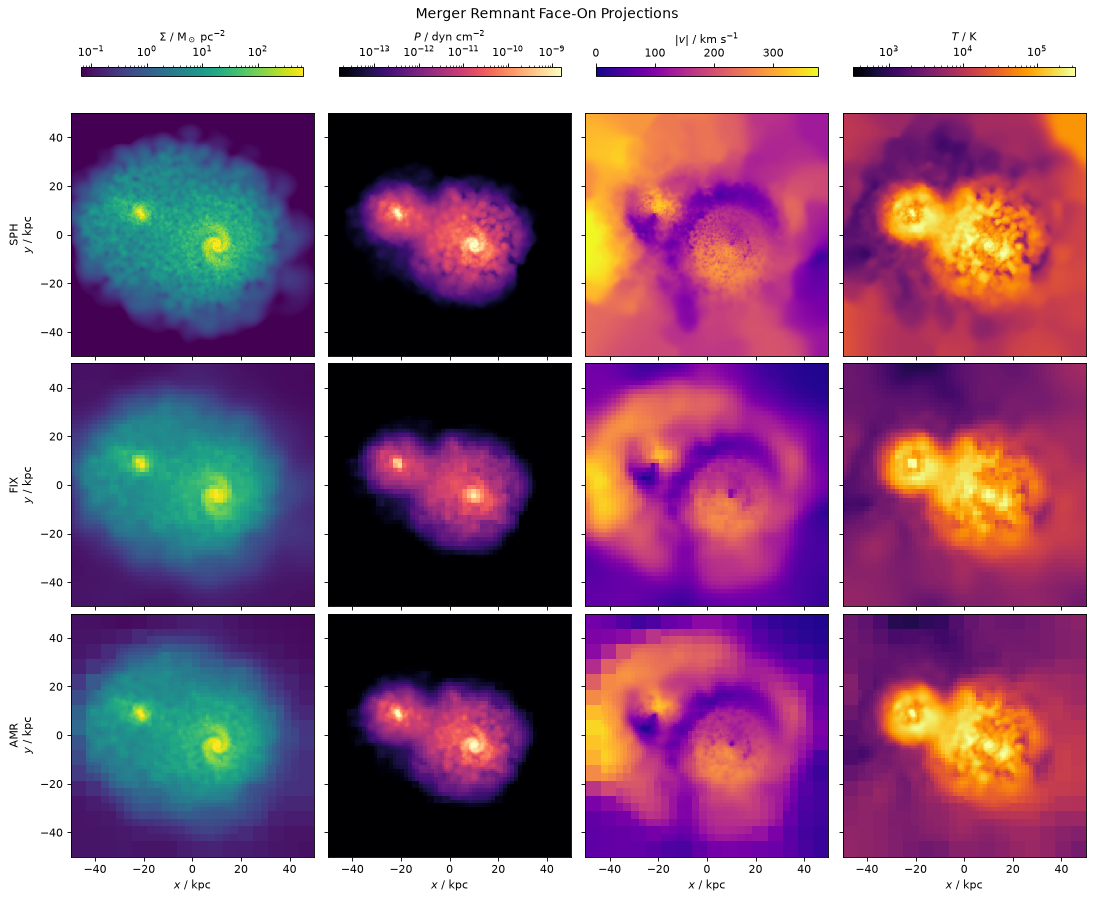

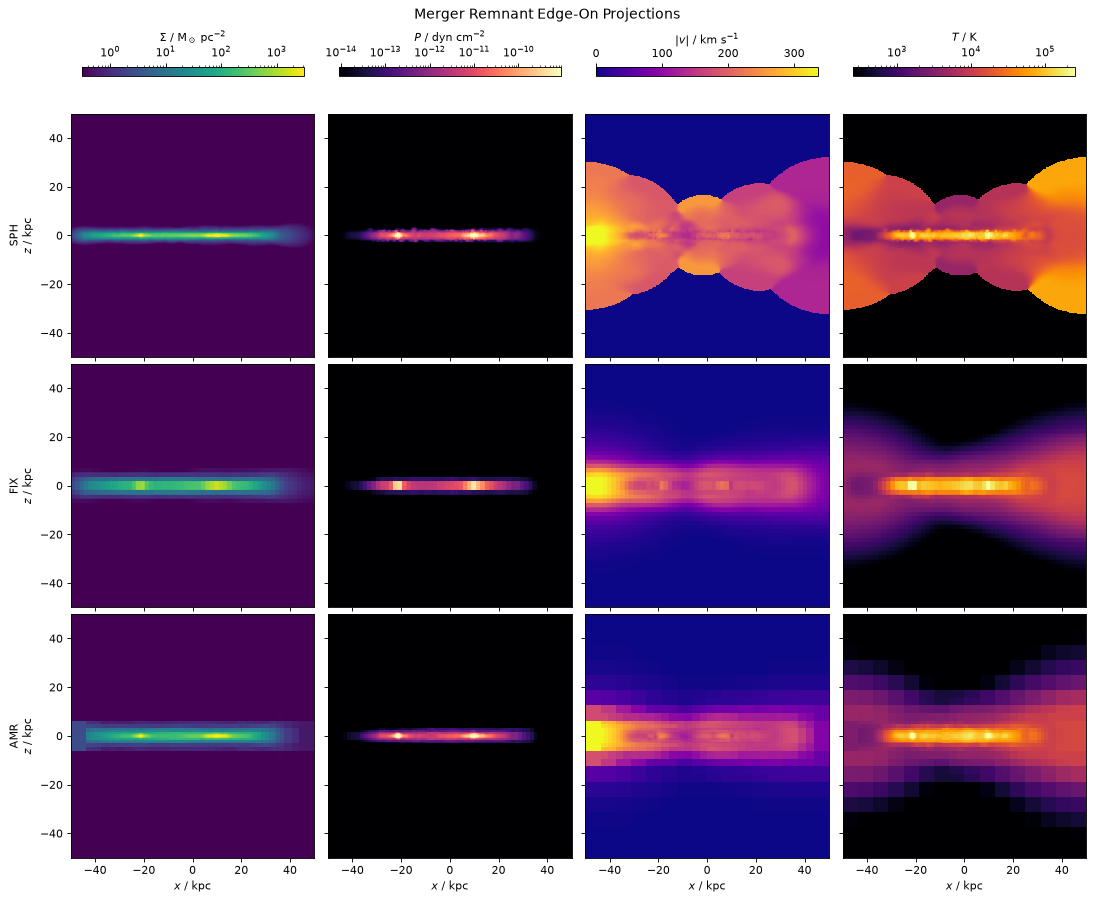

In [11]:
name = "09_merger_remnant"
gal = g.prepare_galaxy(name, results[name])
dsets = {m: g.build_ds(gal, m)[0] for m in g.METHODS}
field_maps(name, gal, dsets)

##### Native yt


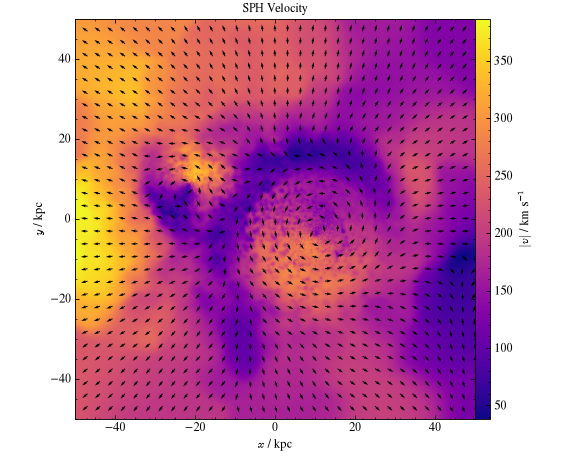

In [12]:
g.yt_plot(dsets["sph"], "z", "proj", field="velocity_magnitude", grids=False, velocity=True,
          title="SPH Velocity")

##### Profiles

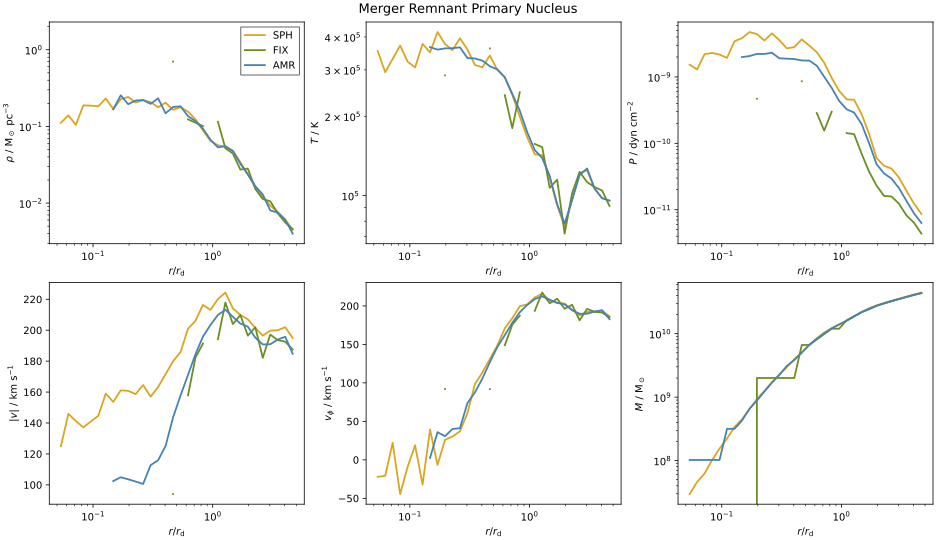

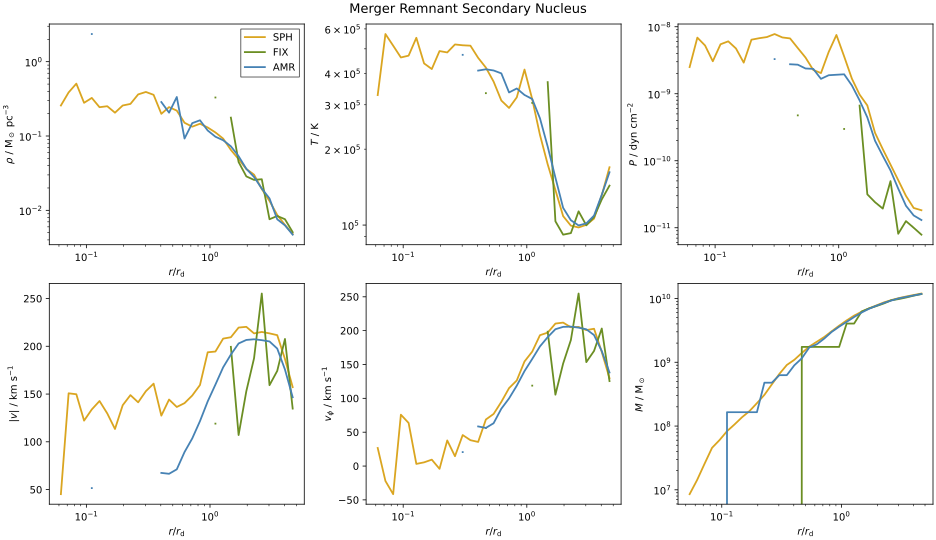

In [13]:
profiles(name, gal, dsets)
del dsets

#### Elliptical E0

Pressure-supported spheroid without rotation at about $2 \times 10^6$ K.

##### Maps

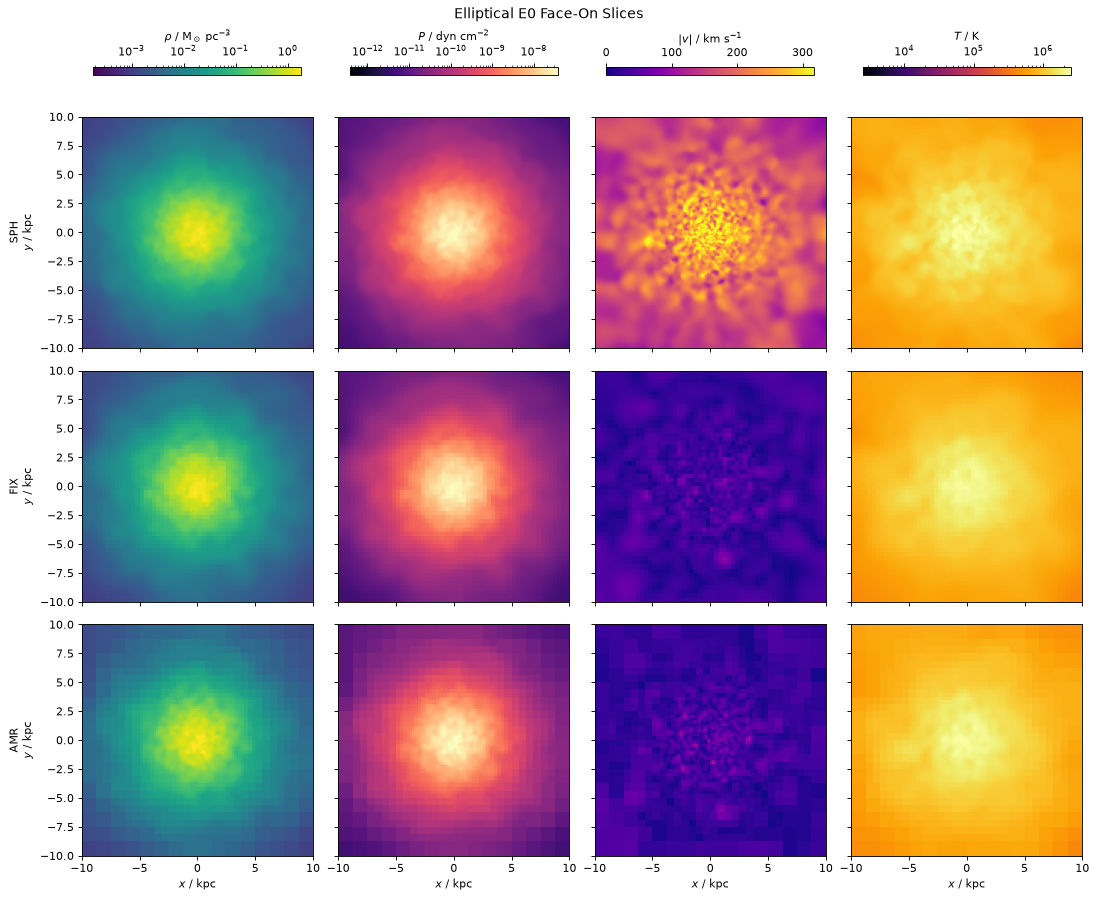

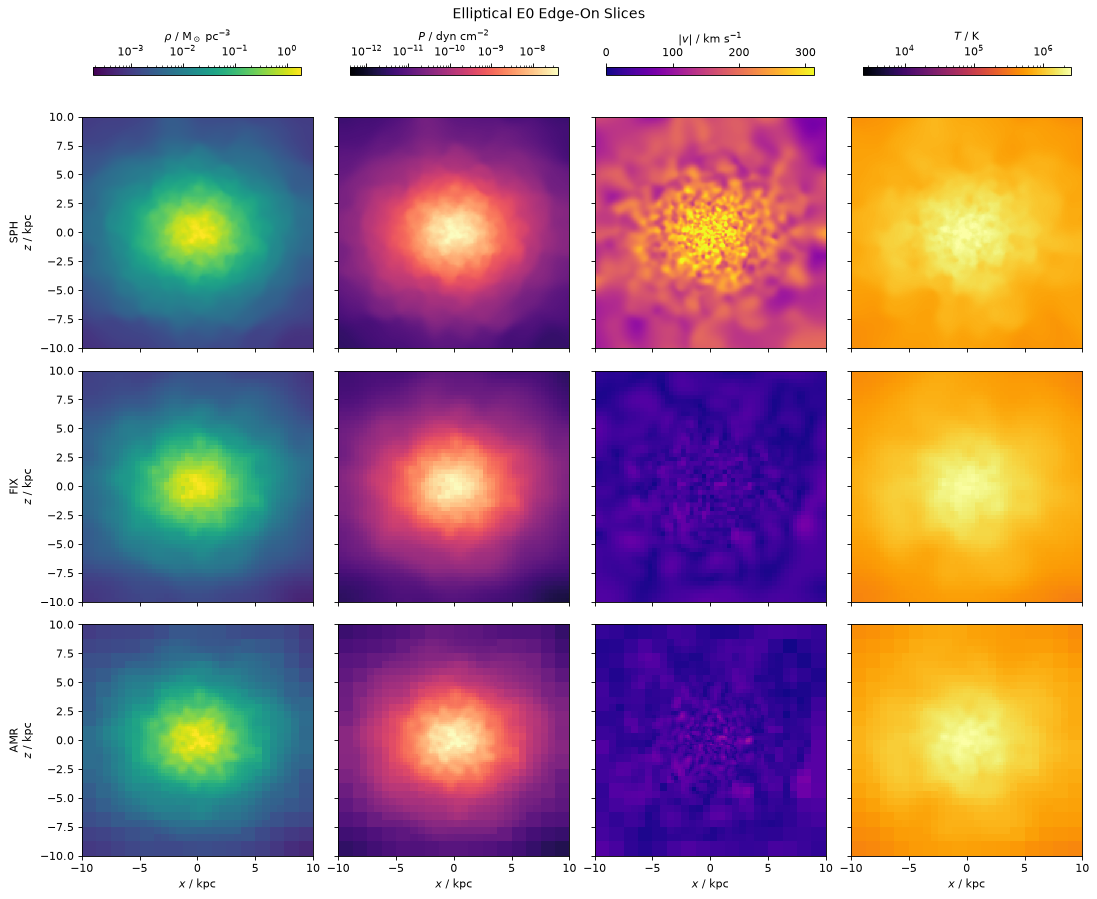

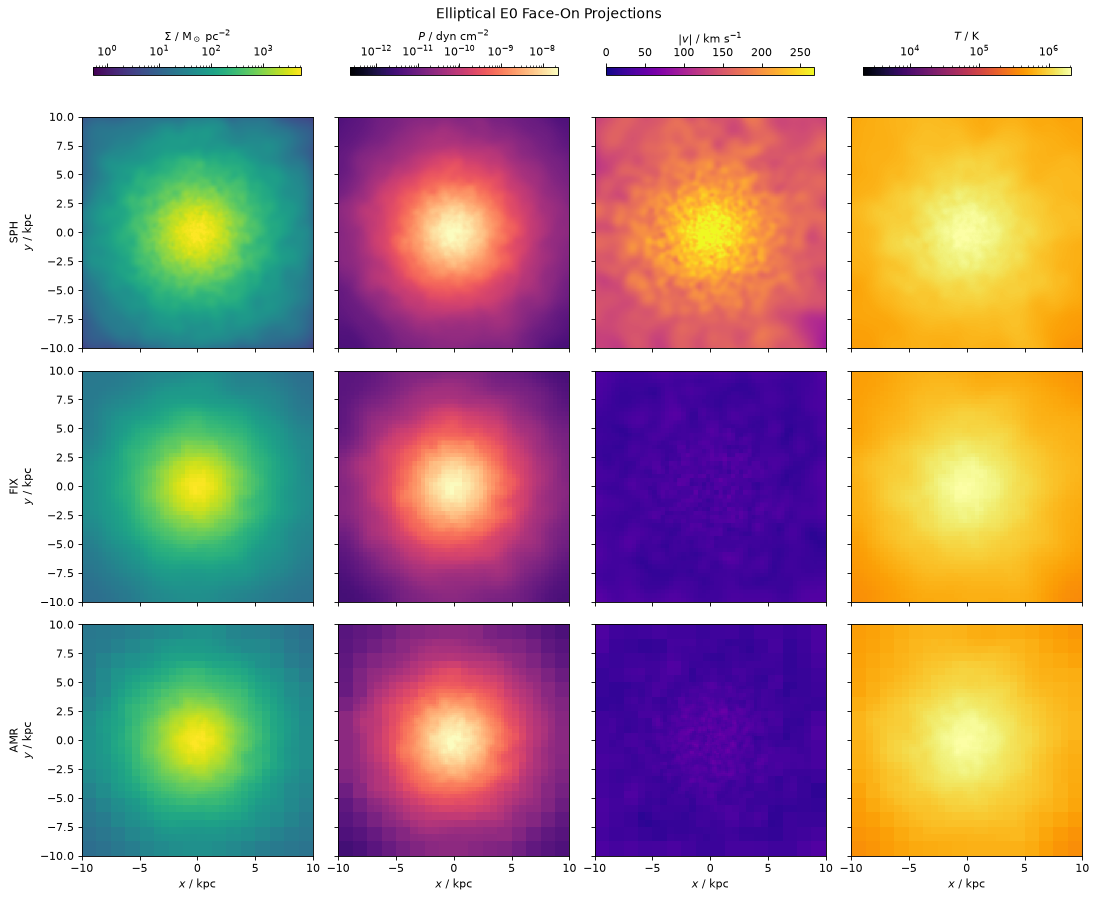

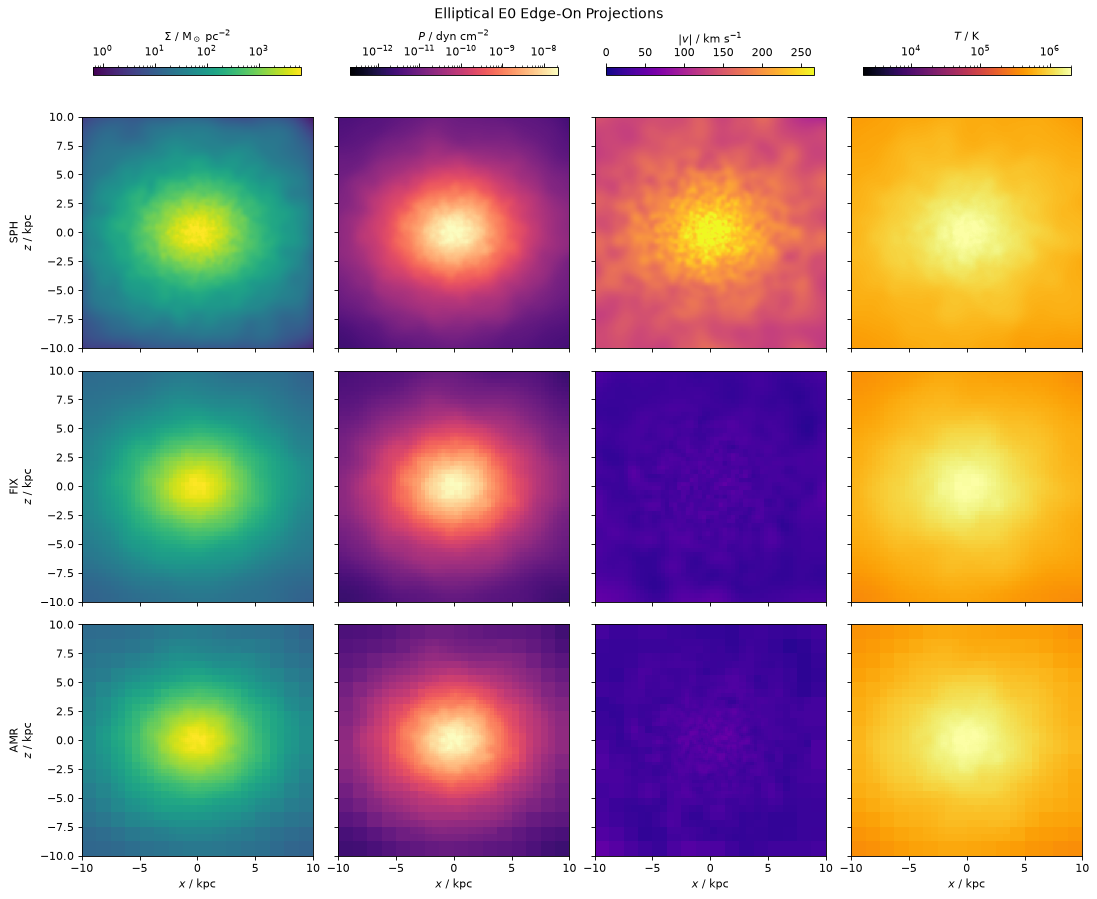

In [14]:
name = "06_elliptical_e0"
gal = g.prepare_galaxy(name, results[name])
dsets = {m: g.build_ds(gal, m)[0] for m in g.METHODS}
field_maps(name, gal, dsets)

##### Native yt


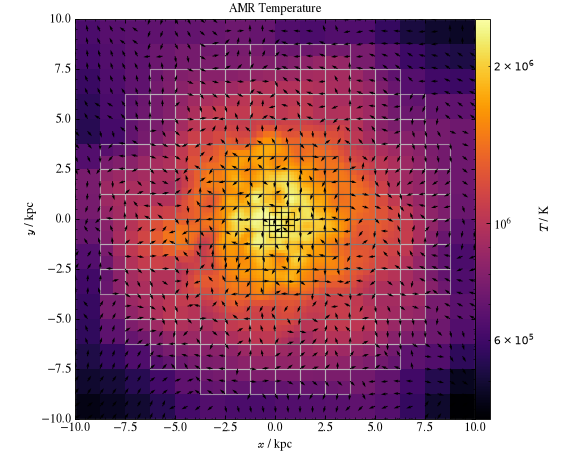

In [15]:
g.yt_plot(dsets["amr"], "z", "slic", field="temperature", grids=True, velocity=True,
          title="AMR Temperature")

##### Profiles

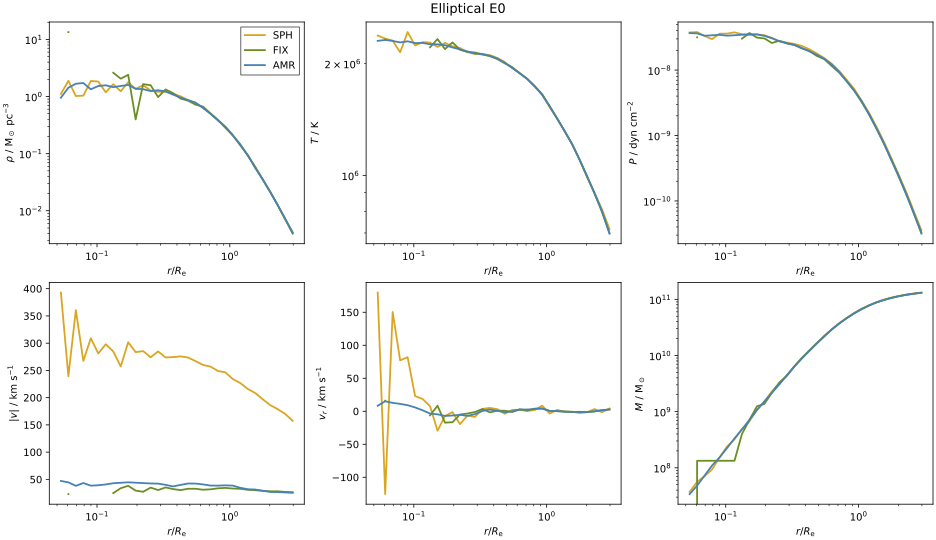

In [16]:
profiles(name, gal, dsets)
del dsets